In [1]:
import numpy as np
from zfish._io import import16chFlt
import matplotlib.pyplot as plt
from tqdm import tqdm
from mylib.statistic_test import *
from zfish.utils import *
from zfish.swim import *
from zfish.local_path import f_dao_opt

d:\Software\Anaconda3\envs\maze\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [78]:
# read behavior
from zfish._io import import16chFlt
from zfish.utils import *
readout_paradigm(import16chFlt(r"D:\EnData\Dao-CoChr\10095\session 1\res.16chFlt"))

'GoDarkGo'

# Session 1

In [ ]:
def plot_godarkgo(path) -> Axes:
    res = import16chFlt(path)
    assert res['Paradigm'][0] == 59595, "Need Godarkgo paradigm data."
    
    base_name = os.path.basename(os.path.dirname(path))
    dir_name = os.path.dirname(os.path.dirname(path))
    save_dir = os.path.join(dir_name, 'analysis_results')
    mkdir(save_dir)

    state = np.zeros(len(res['behav_time']))
    state[res['behav_pos_y'] > 0.5] = 1

    mean_signals = (res['fltCh0'] + res['fltCh1']) / 2

    engagement_score, p_value, engagement_shuf = calc_engagement_score(
        mean_signals, state,
        v_percent=99, n_shuffle=1000
    )
    print(f'Engagement Score: {engagement_score}, p-value: {p_value}')

    
    fig = plt.figure(figsize=(4, 3))
    ax = Clear_Axes(plt.axes(), close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
        
    ax.plot(res['behav_time'], res['fltCh0'], linewidth=0.5, color=ChannelColors[0])
    ax.plot(res['behav_time'], -res['fltCh1'], linewidth=0.5, color=ChannelColors[1])
    ax.plot(res['behav_time'], state*0.0003, linewidth=1, color='k')
    ax.set_title(f'engagement score: {engagement_score:.3f} (p={p_value:.3f})')

    ylim = 0.0008
    ax.set_ylim([-ylim, ylim])
    ax.set_yticks(np.linspace(-ylim, ylim, 5))
    plt.savefig(os.path.join(save_dir, f"{base_name}_engagement.png"))
    plt.savefig(os.path.join(save_dir, f"{base_name}_engagement.svg"))
    plt.show()
    
    # Shuffle test
    fig = plt.figure(figsize=(4, 3))
    ax = Clear_Axes(plt.axes(), close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
    ax.hist(engagement_shuf, bins=40, range=(0, 1), color='gray', alpha=0.7)
    axt = Clear_Axes(ax.twinx(), close_spines=['top', 'left'], ifxticks=True, ifyticks=True)
    sns.ecdfplot(engagement_shuf, ax=axt, color='blue')
    axt.set_ylim(0, 1)
    axt.set_yticks(np.linspace(0, 1, 6))
    axt.spines['right'].set_color('blue')
    ax.axvline(engagement_score, color='red', linestyle='--', label='Observed Score')
    ax.set_xlim([0, 1])
    axt.set_xlim([0, 1])
    plt.savefig(os.path.join(save_dir, f"{base_name}_engagement_shuf_distribution.png"))
    plt.savefig(os.path.join(save_dir, f"{base_name}_engagement_shuf_distribution.svg"))
    plt.show()
    return ax

"""Run the function for each session 1 file in the dataset."""
for i in range(len(f_dao_opt)):
    if f_dao_opt['session'][i] == 1:
        plot_godarkgo(f_dao_opt['filename'][i])

        D:\EnData\Dao-CoChr\10071\analysis_results is already existed!


 90%|█████████ | 903/1000 [00:23<00:02, 39.32it/s]

# Session 2 Manual Set

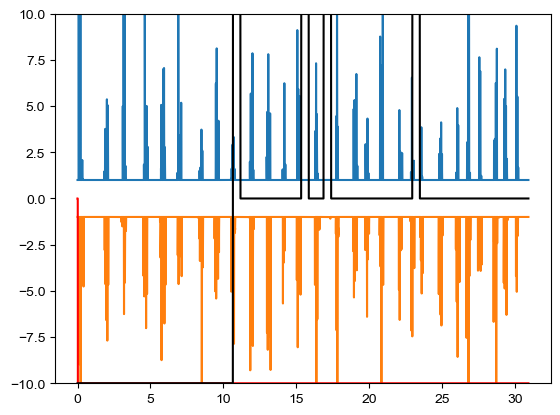

<class 'zfish._classes.SwimDataDict'>


In [30]:
res1d = import16chFlt(r"D:\EnData\Dao-CoChr\10100\session 2\res.16chFlt")
state = np.zeros(len(res1d['behav_time']))
state[res1d['behav_pos_y'] > 98] = 1
opt_state = res1d['opto_states']

def convert(signals):
    signals_norm = signals / np.std(signals)
    signals_norm[signals_norm < 1] = 1
    return signals_norm

plt.plot(res1d['behav_time'], convert(res1d['fltCh0']))
plt.plot(res1d['behav_time'], - convert(res1d['fltCh1']))
plt.plot(res1d['behav_time'], -state*10, c='r')
plt.plot(res1d['behav_time'], opt_state*10, c='k')
plt.ylim([-10, 10])
plt.show()

print(type(res1d))

In [ ]:
from zfish._io import import16chFlt
from zfish.utils import *
from zfish.swim import *
from zfish.local_path import f_dao_opt

def get_gkernel(sigma):
    x = np.arange(-100, 101, 1)
    return np.exp(-x**2/(2*sigma**2)) / (sigma * np.sqrt(2 * np.pi))

def plot_opt_pretest(path: str):
    res = import16chFlt(path)
    res['opto_states'][res['opto_states'] == -1] = 0
    assert res['Paradigm'][0] == 20251114, "Need Optogenetic Pretest paradigm data."
    
    base_name = os.path.basename(os.path.dirname(path))
    dir_name = os.path.dirname(os.path.dirname(path))
    save_dir = os.path.join(dir_name, 'analysis_results', 'Opt Pretest')
    mkdir(save_dir)
    
    # Normalize signals
    gkernel = get_gkernel(sigma=50)
    res['fltCh0'] = (res['fltCh0'] - np.mean(res['fltCh0'])) / np.std(res['fltCh0'])
    res['fltCh1'] = (res['fltCh1'] - np.mean(res['fltCh1'])) / np.std(res['fltCh1'])
    res['fltCh0'] = np.convolve(res['fltCh0'], gkernel, mode='same')
    res['fltCh1'] = np.convolve(res['fltCh1'], gkernel, mode='same')
    
    beg_time = res['behav_time'][0]
    end_time = res['behav_time'][-1]
    excluded_idx = np.where(
        (res['behav_time'] <= beg_time + 2) | (res['behav_time'] >= end_time - 2)
    )[0]
    realigned_data = event_based_realignment(
        res, excluded_idx=excluded_idx
    )
    realigned_data_shuf = event_based_realignment(
        res, excluded_idx=excluded_idx, is_shuffle=True, n_shuffle=10
    )

    n_events = np.unique(realigned_data['n_events'])
    fig = plt.figure(figsize=(4, 2))
    ax = Clear_Axes(plt.axes(), close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
    y_max = max(np.max(realigned_data['realigned_fltCh0']),
                    np.max(realigned_data['realigned_fltCh1'])) * 1.05    
    for i in tqdm(range(n_events.shape[0])):
        event_idx = np.where(realigned_data['n_events'] == n_events[i])[0]
        b = ax.plot(
            realigned_data['realigned_time'][event_idx],
            realigned_data['realigned_fltCh0'][event_idx],
            linewidth=0.5, color=ChannelColors[0], label='Ch0'
        )
        c = ax.plot(
            realigned_data['realigned_time'][event_idx],
            realigned_data['realigned_fltCh1'][event_idx],
            linewidth=0.5, color=ChannelColors[1], label='Ch1'
        )

        d = ax.fill_betweenx(
            [-0.5, y_max * 0.8], 0, 0.5,
            color=LEDColor, alpha=0.3, edgecolor=None,
        )
        a = b + c + [d]
        ax.legend(loc='upper right', fontsize=8)
        ax.set_xlim([-2, 2])
        ax.set_ylim([-0.5, y_max * 0.8])
        ax.set_xticks(np.linspace(-2, 2, 9))
        ax.set_title(f'Event {n_events[i]} Response')
        ax.set_xlabel('Time (s)')
        ax.set_ylabel('Signal')
        plt.savefig(os.path.join(save_dir, f"Trial {i}.png"))
        plt.savefig(os.path.join(save_dir, f"Trial {i}.svg"))
        for item in a:
            item.remove()
    plt.close()

for i in range(len(f_dao_opt)):
    if f_dao_opt['session'][i] == 2:
        plot_opt_pretest(f_dao_opt['filename'][i])
#plot_opt_pretest(r"D:\EnData\Dao-CoChr\10102\session 2\res.16chFlt")

        D:\EnData\Dao-CoChr\10087\analysis_results\Opt Pretest is already existed!


100%|██████████| 20/20 [00:04<00:00,  4.21it/s]


        D:\EnData\Dao-CoChr\10089\analysis_results\Opt Pretest is already existed!


100%|██████████| 21/21 [00:01<00:00, 10.93it/s]


        D:\EnData\Dao-CoChr\10089\analysis_results\Opt Pretest is already existed!


...

100%|██████████| 31/31 [00:03<00:00,  8.88it/s]


        D:\EnData\Dao-CoChr\10101\analysis_results\Opt Pretest is already existed!


100%|██████████| 25/25 [00:02<00:00, 12.01it/s]


        D:\EnData\Dao-CoChr\10102\analysis_results\Opt Pretest is already existed!


100%|██████████| 48/48 [00:04<00:00, 11.52it/s]


# Compute population-level results

In [31]:

idx = np.where((res1d['opto_states'][:-1] == 0) & (np.diff(res1d['opto_states']) == 1))[0]

time_realign = np.zeros_like(res1d['behav_time'])

def get_realigned_params(
    res: dict, 
    realign_idx: np.ndarray, 
    pre_time=2, 
    post_time=2, 
    bin_size=0.05
):
    """Compute speed and swim power with time re-aligned by the input index.

    Parameters
    ----------
    res : dict
        The imported ephys data.
    realign_idx : np.ndarray
        The index of moments to realign the time axis.
    pre_time : float, optional
        The time before the realign index to include, by default 2 (s)
    post_time : float, optional
        The time after the realign index to include, by default 2 (s)
    bin_size : float, optional
        The size of time bins, by default 0.05 (s)
        
    Returns
    -------
    realigned_time : np.ndarray
        The time axis realigned to the input index.
    trial_idx : np.ndarray
        The index of the trials.
    realigned_speed : np.ndarray
        The speed realigned to the input index.
    realigned_swim_power : np.ndarray
        The swim power realigned to the input index.
    """

    n_bins = int((pre_time + post_time) / bin_size)
    realigned_time = np.tile(np.arange(-pre_time, post_time, bin_size)+bin_size/2, (len(realign_idx), 1))
    trial_idx = np.tile(np.arange(len(realign_idx)), (1, n_bins))
    realigned_speed = np.zeros((len(realign_idx), n_bins))
    realigned_swim_power = np.zeros((len(realign_idx), n_bins))
    for i in range(len(realign_idx)):
        
        whole_range = np.where(
            (res['behav_time'] >= res['behav_time'][realign_idx[i]] - pre_time) &
            (res['behav_time'] < res['behav_time'][realign_idx[i]] + post_time)
        )[0]
        behav_time_segment = res['behav_time'][whole_range]
        behav_speed_segment = res['behav_speed_y'][whole_range]
        swim_power_segment = (res['fltCh0'][whole_range] + (res['fltCh1'][whole_range]))/2
        for j, dt in enumerate(np.arange(-pre_time, post_time, bin_size)):
            if j >= n_bins:
                continue
            
            range_idx = np.where(
                (behav_time_segment >= res['behav_time'][realign_idx[i]] + dt) &
                (behav_time_segment < res['behav_time'][realign_idx[i]] + dt + bin_size) &
                (behav_speed_segment > 0)
            )[0]

            realigned_speed[i, j] = np.nanmean(behav_speed_segment[range_idx])
            realigned_swim_power[i, j] = np.nanmean(swim_power_segment[range_idx])

    return realigned_time, trial_idx, realigned_speed, realigned_swim_power

if res1d['Paradigm'][0] in [20250921, 20250920, 20251113, 20251112]:
    state_transition = np.where(np.diff(state) != 0)[0]
    excluded_indices = []
    for i in state_transition:
        transition_time = res1d['behav_time'][i]
        excluded_indices.append(np.where((res1d['behav_time'] >= transition_time - 2) & (res1d['behav_time'] <= transition_time + 2))[0])
    excluded_indices.append(np.where(state == 1)[0])
    excluded_indices = np.unique(np.concatenate(excluded_indices))
else:
    max_t = res1d['behav_time'][-1]
    excluded_indices = np.where(
        (res1d['behav_time'] <= 2) | (res1d['behav_time'] >= max_t - 2)
    )[0]

opt_state = res1d['opto_states']
opt_state[opt_state == -1] = 0
print(np.unique(opt_state))
realigned_data = event_based_realignment(
    res1d,
    state=res1d['opto_states'],
    segmented_keys=['behav_speed_y', 'fltCh0', 'fltCh1'],
    excluded_idx=excluded_indices,
)
realigned_data['Type'] = np.repeat('Opto', realigned_data.shape[0])
realigned_data_shuf = event_based_realignment(
    res1d,
    state=state,
    segmented_keys=['behav_speed_y', 'fltCh0', 'fltCh1'],
    excluded_idx=excluded_indices,
    is_shuffle=True,
    n_shuffle=1000
)
realigned_data_shuf['Type'] = np.repeat('Shuf', realigned_data_shuf.shape[0])
data = realigned_data + realigned_data_shuf

[0 1]


100%|██████████| 1000/1000 [00:21<00:00, 46.50it/s]


In [7]:
print(data.shape)

(0,)


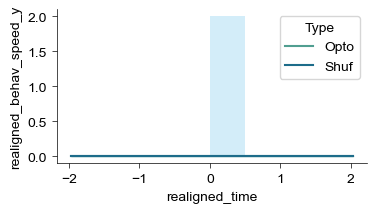

In [10]:
fig = plt.figure(figsize=(4, 2))
ax = Clear_Axes(plt.axes(), close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
ax.fill_betweenx([0, 2], 0, 0.5, color='#a9dcf5', alpha=0.5, edgecolor=None)
sns.lineplot(
    x='realigned_time',
    y='realigned_behav_speed_y',
    hue='Type',
    data=data,
    palette="crest",
    ax=ax
)
plt.show()

NameError: name 'data' is not defined

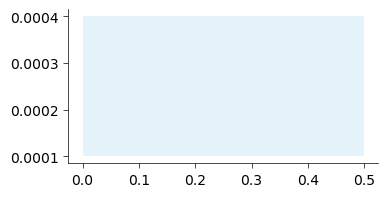

In [2]:
fig = plt.figure(figsize=(4, 2))
ax = Clear_Axes(plt.axes(), close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
ax.fill_betweenx([1e-4, 4e-4], 0, 0.5, color='#a9dcf5', alpha=0.3, edgecolor=None)
data['mean_signals'] = (data['realigned_fltCh0'] + data['realigned_fltCh1']) / 2
sns.lineplot(
    x='realigned_time',
    y='mean_signals',
    hue='Type',
    data=data,
    palette=ChannelColors,
    ax=ax
)
plt.show()